# Experimento 6 — Limites na margem prevista

Mesmas seis features e configurações vencedoras do Exp. 5. Testamos **±20, ±25,
±30, ±40 e sem limite**, aplicando `clip(Pred, -limite, limite)` após a previsão.
O alvo e o treino permanecem iguais. Sem limite reproduz o resultado atual.


## Configuração

Validação expansiva 2021–2025, modelos M/W separados e média simples dos cinco
Logistic Briers combinados. Reutilizamos os parâmetros escolhidos pelo Optuna no
Exp. 5 para isolar o efeito do limite; não repetimos a busca de hiperparâmetros.

Selecionamos um limite por modelo, comum às duas categorias. Em empate exato,
preferimos sem limite, depois o maior limite. Estes anos são de seleção, não teste independente.


In [1]:
from pathlib import Path
import sys
import json
from importlib.metadata import version

import numpy as np
import pandas as pd
from IPython.display import display

pasta_atual = Path.cwd().resolve()
raiz = next(
    (p for p in [pasta_atual, *pasta_atual.parents] if (p / "raw_data").is_dir()),
    None,
)
if raiz is None:
    raise FileNotFoundError("Pasta raw_data não encontrada.")
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from src.data_processing import carregar_dados, preparar_seeds, organizar_jogos
from src.features import adicionar_seeds, calcular_winrate
from src.models import criar_regressao_linear, criar_random_forest, criar_xgboost
from src.tuning import avaliar_temporadas
from src.metrics import logistic_brier
from src.submission import preparar_confrontos, prever_confrontos, salvar_submission

EXPERIMENTO = "exp6_limite_margem"
FEATURES = ["SeedDif", "WinRateDiff", "AvgPointsForDiff", "AvgPointsAgainstDiff", "OppWinRateDiff", "EloDiff"]
ANOS_VALIDACAO = list(range(2021, 2026))
TEMPORADA_PREVISAO = 2026
SEED = 42
N_JOBS_MODELO = 2
CATEGORIAS = {"M": "Masculino", "W": "Feminino"}
CRIADORES = {
    "linear": criar_regressao_linear,
    "random_forest": criar_random_forest,
    "xgboost": criar_xgboost,
}
NOMES = {"linear": "Regressão linear", "random_forest": "Random Forest", "xgboost": "XGBoost"}

from src.features import calcular_estatisticas_agregadas, adicionar_estatisticas
from src.features import calcular_elo, adicionar_elo
LIMITE_DAYNUM_PREVISAO = 134
K_ELO = 20
ELO_INICIAL = 1500
LIMITES = {"20": 20, "25": 25, "30": 30, "40": 40, "Sem limite": None}
ORDEM_EMPATE = {"Sem limite": 0, "40": 1, "30": 2, "25": 3, "20": 4}

REFERENCIA_EXP5 = json.loads(r'''{"features": ["SeedDif", "WinRateDiff", "AvgPointsForDiff", "AvgPointsAgainstDiff", "OppWinRateDiff", "EloDiff"], "anos_validacao": [2021, 2022, 2023, 2024, 2025], "seed": 42, "melhores_parametros": {"linear": {"fit_intercept": true}, "random_forest": {"random_state": 42, "n_jobs": 2, "n_estimators": 400, "max_depth": 4, "min_samples_leaf": 8, "max_features": 0.5, "max_samples": 0.644195294768407}, "xgboost": {"random_state": 42, "n_jobs": 2, "objective": "reg:squarederror", "tree_method": "hist", "n_estimators": 150, "max_depth": 3, "learning_rate": 0.01097599850212944, "min_child_weight": 62.215825966390064, "subsample": 0.7035119926400067, "colsample_bytree": 0.5, "reg_alpha": 0.013194961490425657, "reg_lambda": 4.366473592979633, "gamma": 0.9242722776276352}}, "melhores_medias": {"linear": 0.07065620546024257, "random_forest": 0.069153571533485, "xgboost": 0.06803421645873116}, "versoes": {"numpy": "2.2.6", "pandas": "2.3.2", "scikit-learn": "1.7.1", "xgboost": "3.0.5", "optuna": "4.9.0"}, "n_trials": {"linear": 2, "random_forest": 30, "xgboost": 30}, "espacos_busca": {"linear": {"fit_intercept": {"tipo": "categorical", "choices": [false, true]}}, "random_forest": {"n_estimators": {"tipo": "int", "low": 150, "high": 500, "step": 50}, "max_depth": {"tipo": "categorical", "choices": [2, 3, 4, 6, 8, 12, null]}, "min_samples_leaf": {"tipo": "int", "low": 2, "high": 80, "log": true}, "max_features": {"tipo": "categorical", "choices": [0.5, 1.0]}, "max_samples": {"tipo": "float", "low": 0.6, "high": 1.0}}, "xgboost": {"n_estimators": {"tipo": "int", "low": 100, "high": 600, "step": 50}, "max_depth": {"tipo": "int", "low": 1, "high": 5}, "learning_rate": {"tipo": "float", "low": 0.01, "high": 0.15, "log": true}, "min_child_weight": {"tipo": "float", "low": 5.0, "high": 80.0, "log": true}, "subsample": {"tipo": "float", "low": 0.6, "high": 1.0}, "colsample_bytree": {"tipo": "categorical", "choices": [0.5, 1.0]}, "reg_alpha": {"tipo": "float", "low": 1e-05, "high": 10.0, "log": true}, "reg_lambda": {"tipo": "float", "low": 0.1, "high": 100.0, "log": true}, "gamma": {"tipo": "float", "low": 0.0, "high": 5.0}}}, "fonte": "notebooks/features_incrementais/exp5_elo.ipynb: registro do experimento"}''')

REFERENCIA_EXP4 = json.loads(r'''{"melhores_parametros": {"linear": {"fit_intercept": true}, "random_forest": {"random_state": 42, "n_jobs": 2, "n_estimators": 500, "max_depth": 4, "min_samples_leaf": 6, "max_features": 0.5, "max_samples": 0.6065760550178787}, "xgboost": {"random_state": 42, "n_jobs": 2, "objective": "reg:squarederror", "tree_method": "hist", "n_estimators": 150, "max_depth": 3, "learning_rate": 0.012689764289026415, "min_child_weight": 8.607635238510117, "subsample": 0.6580133184316654, "colsample_bytree": 0.5, "reg_alpha": 0.0024896301334778855, "reg_lambda": 2.8889382262130026, "gamma": 0.6608413857851283}}, "melhores_medias": {"linear": 0.07102647699289884, "random_forest": 0.06868149782959243, "xgboost": 0.06756812913405244}, "versoes": {"numpy": "2.2.6", "pandas": "2.3.2", "scikit-learn": "1.7.1", "xgboost": "3.0.5", "optuna": "4.9.0"}, "fonte": "notebooks\\features_incrementais\\exp4_features_agregadas.ipynb: registro do experimento"}''')

PARAMETROS = REFERENCIA_EXP5["melhores_parametros"]
assert FEATURES == REFERENCIA_EXP5["features"]
assert ANOS_VALIDACAO == REFERENCIA_EXP5["anos_validacao"]


## Preparar dados

Mesmo recorte pré-torneio do Exp. 5, com verificações de datas, categorias,
features finitas e diferenças A − B. Para 2026: DayNum < 134.


In [2]:
dados = {
    categoria: carregar_dados(raiz / "raw_data", categoria, incluir_regular=True)
    for categoria in CATEGORIAS
}
assert set(dados["M"]["times"]["TeamID"]).isdisjoint(set(dados["W"]["times"]["TeamID"]))
seeds, estatisticas, elos, jogos, limites, auditoria = {}, {}, {}, {}, {}, []
for categoria, base in dados.items():
    torneios = base["resultados"].loc[base["resultados"]["Season"] < TEMPORADA_PREVISAO].copy()
    limites[categoria] = torneios.groupby("Season")["DayNum"].min().to_dict()
    limites[categoria][TEMPORADA_PREVISAO] = LIMITE_DAYNUM_PREVISAO
    regulares = base["temporada_regular"].loc[
        base["temporada_regular"]["Season"].isin(limites[categoria])
    ].copy()
    assert (regulares["DayNum"] < regulares["Season"].map(limites[categoria])).all()
    assert regulares.merge(
        torneios[["Season", "DayNum", "WTeamID", "LTeamID"]],
        on=["Season", "DayNum", "WTeamID", "LTeamID"],
    ).empty, "Sobreposição entre jogos regulares e NCAA."
    ids_categoria = set(base["times"]["TeamID"])
    assert regulares["WTeamID"].isin(ids_categoria).all()
    assert regulares["LTeamID"].isin(ids_categoria).all()

    seeds[categoria] = preparar_seeds(base["seeds"])
    estatisticas[categoria] = calcular_estatisticas_agregadas(
        regulares, limites_daynum=limites[categoria],
    )
    elos[categoria] = calcular_elo(
        regulares, limites_daynum=limites[categoria], k=K_ELO, elo_inicial=ELO_INICIAL,
    )
    assert not elos[categoria].duplicated(["Season", "TeamID"]).any()
    totais = elos[categoria].groupby("Season")["Elo"].agg(["sum", "size"])
    np.testing.assert_allclose(totais["sum"], totais["size"] * ELO_INICIAL)
    # Compatibilidade do win rate de temporada inteira com o Experimento 2.
    taxas_antigas = calcular_winrate(regulares).set_index(["Season", "TeamID"])
    stats_index = estatisticas[categoria].set_index(["Season", "TeamID"])
    np.testing.assert_allclose(stats_index["WinRate"], taxas_antigas.loc[stats_index.index, "WinRate"])
    assert not estatisticas[categoria].duplicated(["Season", "TeamID"]).any()

    base_jogos = adicionar_seeds(organizar_jogos(torneios), seeds[categoria])
    jogos[categoria] = adicionar_estatisticas(base_jogos, estatisticas[categoria])
    jogos[categoria] = adicionar_elo(jogos[categoria], elos[categoria])
    tabela = jogos[categoria]
    assert len(tabela) == len(torneios)
    assert (tabela["TeamA"] < tabela["TeamB"]).all()
    assert tabela["Target"].equals(tabela["ScoreA"] - tabela["ScoreB"])
    assert tabela["SeedDif"].equals(tabela["SeedA"] - tabela["SeedB"])
    assert np.isfinite(tabela[FEATURES].to_numpy()).all()
    assert tabela["TeamA"].isin(ids_categoria).all() and tabela["TeamB"].isin(ids_categoria).all()
    chave_a = pd.MultiIndex.from_frame(tabela[["Season", "TeamA"]])
    chave_b = pd.MultiIndex.from_frame(tabela[["Season", "TeamB"]])
    for nome in ["WinRate", "AvgPointsFor", "AvgPointsAgainst", "OppWinRate"]:
        esperado = stats_index[nome].reindex(chave_a).to_numpy() - stats_index[nome].reindex(chave_b).to_numpy()
        np.testing.assert_allclose(tabela[f"{nome}Diff"], esperado)

    elo_index = elos[categoria].set_index(["Season", "TeamID"])["Elo"]
    np.testing.assert_allclose(tabela["EloDiff"],
        elo_index.reindex(chave_a).to_numpy() - elo_index.reindex(chave_b).to_numpy())

    for ano, grupo in regulares.groupby("Season"):
        auditoria.append({
            "Categoria": categoria, "Season": ano, "JogosRegulares": len(grupo),
            "UltimoDayNumRegular": grupo["DayNum"].max(), "LimiteExclusivo": limites[categoria][ano],
        })

auditoria = pd.DataFrame(auditoria)
display(auditoria.loc[auditoria["Season"] >= min(ANOS_VALIDACAO)])
divisoes = pd.DataFrame([
    {
        "AnoValidacao": ano, "Categoria": CATEGORIAS[categoria],
        "UltimoAnoTreino": tabela.loc[tabela["Season"] < ano, "Season"].max(),
        "JogosTreino": tabela["Season"].lt(ano).sum(),
        "JogosValidacao": tabela["Season"].eq(ano).sum(),
    }
    for ano in ANOS_VALIDACAO for categoria, tabela in jogos.items()
])
assert divisoes["JogosValidacao"].gt(0).all()
assert (divisoes["UltimoAnoTreino"] < divisoes["AnoValidacao"]).all()
assert divisoes.loc[divisoes["AnoValidacao"].eq(2021), "UltimoAnoTreino"].eq(2019).all()
display(divisoes)
display(jogos["M"][["Season", "TeamA", "TeamB", *FEATURES, "Target"]].head())


,Categoria,Season,JogosRegulares,UltimoDayNumRegular,LimiteExclusivo
35,M,2021,3855,132,136
36,M,2022,5345,132,134
37,M,2023,5602,132,134
38,M,2024,5607,132,134
39,M,2025,5641,132,134
40,M,2026,5647,132,134
63,W,2021,3556,132,139
64,W,2022,5060,132,135
65,W,2023,5374,132,135
66,W,2024,5414,132,135


,AnoValidacao,Categoria,UltimoAnoTreino,JogosTreino,JogosValidacao
0,2021,Masculino,2019,2251,66
1,2021,Feminino,2019,1386,63
2,2022,Masculino,2021,2317,67
3,2022,Feminino,2021,1449,67
4,2023,Masculino,2022,2384,67
5,2023,Feminino,2022,1516,67
6,2024,Masculino,2023,2451,67
7,2024,Feminino,2023,1583,67
8,2025,Masculino,2024,2518,67
9,2025,Feminino,2024,1650,67


,Season,TeamA,TeamB,SeedDif,WinRateDiff,AvgPointsForDiff,AvgPointsAgainstDiff,OppWinRateDiff,EloDiff,Target
0,1985,1116,1234,1,-0.030303,-4.400000,2.430303,0.020862,-0.563602,9
1,1985,1120,1345,5,-0.059310,1.224828,1.335172,0.002403,-17.506832,1
2,1985,1207,1250,-15,0.546616,9.982120,-10.132822,0.131907,234.650780,25
3,1985,1229,1425,1,0.062169,3.199735,1.022487,-0.033687,13.613385,3
4,1985,1242,1325,-11,0.025926,8.477778,7.400000,0.065588,18.192012,11


## Previsões de validação

Cada modelo é ajustado separadamente por categoria e ano, usando apenas anos anteriores.
Os cinco limites usam exatamente as mesmas previsões de validação.


In [3]:
avaliacoes = {}
for nome, criar_modelo in CRIADORES.items():
    avaliacoes[nome] = avaliar_temporadas(
        jogos, criar_modelo(**PARAMETROS[nome]), ANOS_VALIDACAO, features=FEATURES,
    )
    np.testing.assert_allclose(
        avaliacoes[nome]["media"], REFERENCIA_EXP5["melhores_medias"][nome], rtol=1e-6,
    )
    print(NOMES[nome], PARAMETROS[nome])


Regressão linear {'fit_intercept': True}
Random Forest {'random_state': 42, 'n_jobs': 2, 'n_estimators': 400, 'max_depth': 4, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_samples': 0.644195294768407}
XGBoost {'random_state': 42, 'n_jobs': 2, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.01097599850212944, 'min_child_weight': 62.215825966390064, 'subsample': 0.7035119926400067, 'colsample_bytree': 0.5, 'reg_alpha': 0.013194961490425657, 'reg_lambda': 4.366473592979633, 'gamma': 0.9242722776276352}


## Comparação dos cinco limites

Ganho positivo significa redução do erro em relação a sem limite.
A escolha usa as médias sem arredondamento; cada ano recebe o mesmo peso.


In [4]:
linhas = []
for nome, avaliacao in avaliacoes.items():
    for rotulo, limite in LIMITES.items():
        previsoes = avaliacao["previsoes"].copy()
        brutas = previsoes["Pred"].to_numpy(copy=True)
        previsoes["Pred"] = brutas if limite is None else np.clip(brutas, -limite, limite)
        previsoes["Limitada"] = previsoes["Pred"].to_numpy() != brutas
        assert np.isfinite(previsoes["Pred"]).all()
        np.testing.assert_array_equal(previsoes["Target"], avaliacao["previsoes"]["Target"])
        if limite is not None:
            assert previsoes["Pred"].abs().le(limite).all()
            np.testing.assert_array_equal(np.sign(previsoes["Pred"]), np.sign(brutas))
        for ano in ANOS_VALIDACAO:
            anual = previsoes.loc[previsoes["Season"].eq(ano)]
            for categoria in [*CATEGORIAS, "Combinado"]:
                grupo = anual if categoria == "Combinado" else anual.loc[anual["Categoria"].eq(categoria)]
                linhas.append({
                    "Modelo": NOMES[nome], "ChaveModelo": nome, "Limite": rotulo,
                    "Season": ano, "Categoria": categoria,
                    "Score": logistic_brier(grupo["Target"], grupo["Pred"]),
                    "Jogos": len(grupo), "PrevisoesLimitadas": int(grupo["Limitada"].sum()),
                })

scores_anuais = pd.DataFrame(linhas)
combinados = scores_anuais.query("Categoria == 'Combinado'")
assert combinados.groupby(["ChaveModelo", "Limite"]).size().eq(5).all()
resumo = combinados.groupby(["ChaveModelo", "Modelo", "Limite"], as_index=False).agg(
    MediaLogisticBrier=("Score", "mean"), PrevisoesLimitadas=("PrevisoesLimitadas", "sum"),
)
sem_limite = resumo.loc[resumo["Limite"].eq("Sem limite")].set_index("ChaveModelo")["MediaLogisticBrier"]
resumo["GanhoVsSemLimite"] = resumo["ChaveModelo"].map(sem_limite) - resumo["MediaLogisticBrier"]
for nome in CRIADORES:
    np.testing.assert_allclose(sem_limite[nome], avaliacoes[nome]["media"], rtol=1e-12)

display(resumo.pivot(index="Limite", columns="Modelo", values=["MediaLogisticBrier", "GanhoVsSemLimite"])
        .reindex(list(LIMITES)).round(8))
display(resumo.pivot(index="Limite", columns="Modelo", values="PrevisoesLimitadas").reindex(list(LIMITES)))

melhores = (resumo.assign(Desempate=resumo["Limite"].map(ORDEM_EMPATE))
    .sort_values(["MediaLogisticBrier", "Desempate"])
    .drop_duplicates("ChaveModelo").drop(columns="Desempate"))
melhores_rotulos = melhores.set_index("ChaveModelo")["Limite"].to_dict()
melhores_limites = {nome: LIMITES[rotulo] for nome, rotulo in melhores_rotulos.items()}
display(melhores[["Modelo", "Limite", "MediaLogisticBrier", "GanhoVsSemLimite"]].round(8))
display(combinados.pivot(index=["Modelo", "Season"], columns="Limite", values="Score")
        .reindex(columns=list(LIMITES)).round(8))

comparacao = pd.DataFrame([
    {"Modelo": NOMES[nome], "Exp4": REFERENCIA_EXP4["melhores_medias"][nome],
     "Exp5SemLimite": sem_limite[nome], "Exp6MelhorLimite": float(melhores.loc[melhores["ChaveModelo"].eq(nome), "MediaLogisticBrier"].iloc[0]),
     "LimiteEscolhido": melhores_rotulos[nome]}
    for nome in CRIADORES
])
display(comparacao.round(8))


MediaLogisticBrier                            GanhoVsSemLimite  \
Modelo          Random Forest Regressão linear   XGBoost    Random Forest   
Limite                                                                      
20                   0.069192         0.070701  0.068082    -3.800000e-05   
25                   0.069165         0.070668  0.068036    -1.162000e-05   
30                   0.069155         0.070657  0.068034    -9.600000e-07   
40                   0.069154         0.070656  0.068034    -0.000000e+00   
Sem limite           0.069154         0.070656  0.068034     0.000000e+00   

                                           
Modelo     Regressão linear       XGBoost  
Limite                                     
20                -0.000045 -4.755000e-05  
25                -0.000012 -2.250000e-06  
30                -0.000001 -5.000000e-08  
40                 0.000000  0.000000e+00  
Sem limite         0.000000  0.000000e+00

Modelo,Random Forest,Regressão linear,XGBoost
Limite,,,
20,65,80,33
25,31,42,8
30,13,21,1
40,1,5,0
Sem limite,0,0,0


,Modelo,Limite,MediaLogisticBrier,GanhoVsSemLimite
14,XGBoost,Sem limite,0.068034,0.0
9,Random Forest,Sem limite,0.069154,0.0
3,Regressão linear,40,0.070656,0.0


Limite                         20        25        30        40  Sem limite
Modelo           Season                                                    
Random Forest    2021    0.082546  0.082615  0.082607  0.082607    0.082607
                 2022    0.078399  0.078301  0.078291  0.078290    0.078290
                 2023    0.078928  0.078995  0.078985  0.078985    0.078985
                 2024    0.053795  0.053719  0.053711  0.053711    0.053711
                 2025    0.052288  0.052195  0.052178  0.052175    0.052175
Regressão linear 2021    0.088909  0.088868  0.088854  0.088854    0.088854
                 2022    0.077743  0.077662  0.077644  0.077643    0.077643
                 2023    0.080046  0.080137  0.080124  0.080124    0.080124
                 2024    0.059464  0.059475  0.059483  0.059483    0.059483
                 2025    0.047342  0.047200  0.047181  0.047177    0.047177
XGBoost          2021    0.079092  0.079098  0.079095  0.079095    0.079095
                 2022    0.074336  0.074285  0.074285  0.074285    0.074285
                 2023    0.075172  0.075103  0.075102  0.075102    0.075102
                 2024    0.056739  0.056701  0.056700  0.056700    0.056700
                 2025    0.055069  0.054995  0.054989  0.054989    0.054989

,Modelo,Exp4,Exp5SemLimite,Exp6MelhorLimite,LimiteEscolhido
0,Regressão linear,0.071026,0.070656,0.070656,40
1,Random Forest,0.068682,0.069154,0.069154,Sem limite
2,XGBoost,0.067568,0.068034,0.068034,Sem limite


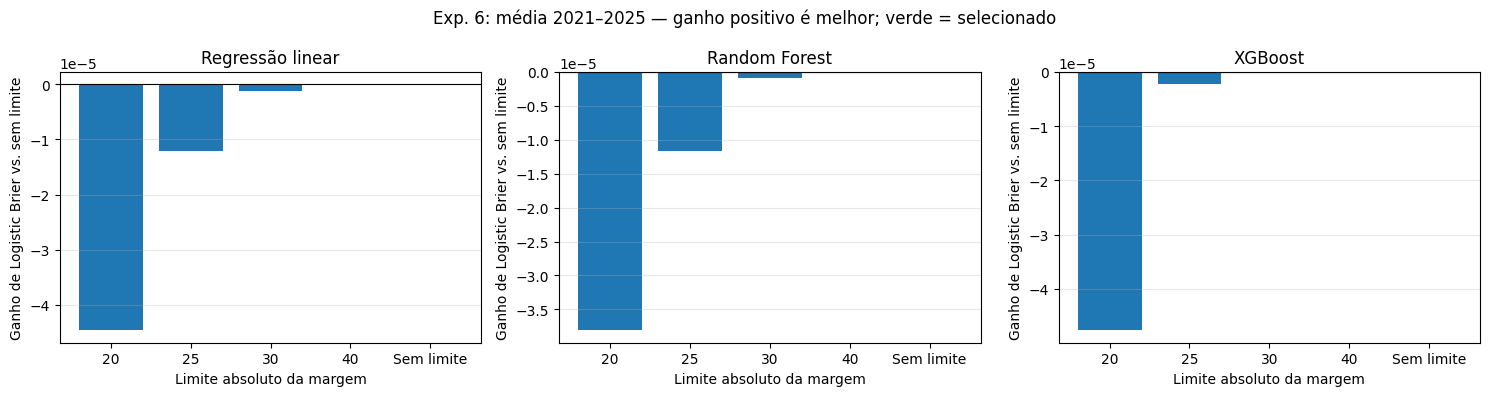

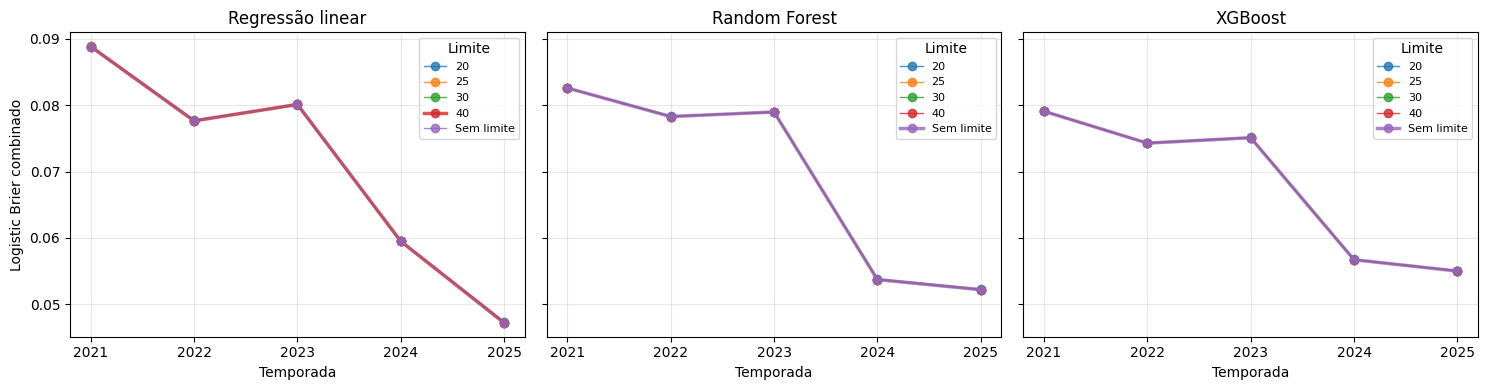

In [5]:
import matplotlib.pyplot as plt

fig, eixos = plt.subplots(1, 3, figsize=(15, 4))
for ax, nome in zip(eixos, CRIADORES):
    tabela = resumo.loc[resumo["ChaveModelo"].eq(nome)].set_index("Limite").reindex(list(LIMITES))
    cores = ["tab:green" if rotulo == melhores_rotulos[nome] else "tab:blue" for rotulo in tabela.index]
    ax.bar(tabela.index, tabela["GanhoVsSemLimite"], color=cores)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(NOMES[nome])
    ax.set_xlabel("Limite absoluto da margem")
    ax.set_ylabel("Ganho de Logistic Brier vs. sem limite")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Exp. 6: média 2021–2025 — ganho positivo é melhor; verde = selecionado")
fig.tight_layout()
plt.show()

fig_anos, eixos = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, nome in zip(eixos, CRIADORES):
    for rotulo in LIMITES:
        tabela = combinados.loc[combinados["ChaveModelo"].eq(nome) & combinados["Limite"].eq(rotulo)]
        ax.plot(tabela["Season"], tabela["Score"], marker="o", label=rotulo,
                linewidth=2.5 if rotulo == melhores_rotulos[nome] else 1, alpha=0.8)
    ax.set_title(NOMES[nome])
    ax.set_xticks(ANOS_VALIDACAO)
    ax.set_xlabel("Temporada")
    ax.grid(alpha=0.3)
    ax.legend(title="Limite", fontsize=8)
eixos[0].set_ylabel("Logistic Brier combinado")
fig_anos.tight_layout()
plt.show()


## Submissões de 2026

Treino final até 2025 com os parâmetros do Exp. 5; aplicamos o limite selecionado
para cada modelo. CSV com margens em pontos, sem sigmoid, mantendo o fallback zero.


In [6]:
sample_submission = dados["M"]["sample_submission"]
confrontos = preparar_confrontos(
    sample_submission, seeds["M"], seeds["W"],
    dados["M"]["times"]["TeamID"], dados["W"]["times"]["TeamID"],
    temporada=TEMPORADA_PREVISAO,
)
stats_2026 = pd.concat([
    stats.loc[stats["Season"].eq(TEMPORADA_PREVISAO)]
    for stats in estatisticas.values()
], ignore_index=True)
confrontos = adicionar_estatisticas(confrontos, stats_2026, permitir_ausentes=True)
elos_2026 = pd.concat([
    tabela.loc[tabela["Season"].eq(TEMPORADA_PREVISAO)] for tabela in elos.values()
], ignore_index=True)
confrontos = adicionar_elo(confrontos, elos_2026, permitir_ausentes=True)
participantes = confrontos["TemDuasSeeds"]
assert (confrontos["TeamA"] < confrontos["TeamB"]).all()
assert np.isfinite(confrontos.loc[participantes, FEATURES].to_numpy()).all()
stats_index = stats_2026.set_index(["Season", "TeamID"])
pares = confrontos.loc[participantes]
for nome in ["WinRate", "AvgPointsFor", "AvgPointsAgainst", "OppWinRate"]:
    a = stats_index[nome].reindex(pd.MultiIndex.from_frame(pares[["Season", "TeamA"]])).to_numpy()
    b = stats_index[nome].reindex(pd.MultiIndex.from_frame(pares[["Season", "TeamB"]])).to_numpy()
    np.testing.assert_allclose(pares[f"{nome}Diff"], a - b)

elo_index = elos_2026.set_index(["Season", "TeamID"])["Elo"]
np.testing.assert_allclose(pares["EloDiff"],
    elo_index.reindex(pd.MultiIndex.from_frame(pares[["Season", "TeamA"]])).to_numpy()
    - elo_index.reindex(pd.MultiIndex.from_frame(pares[["Season", "TeamB"]])).to_numpy())

modelos_finais, arquivos_submission, resumo_submissions = {}, {}, []
for nome, criar_modelo in CRIADORES.items():
    modelos_finais[nome] = {}
    for categoria, tabela in jogos.items():
        treino = tabela.loc[tabela["Season"] < TEMPORADA_PREVISAO]
        assert treino["Season"].max() == 2025
        assert treino["TeamA"].isin(dados[categoria]["times"]["TeamID"]).all()
        assert treino["TeamB"].isin(dados[categoria]["times"]["TeamID"]).all()
        modelo = criar_modelo(**PARAMETROS[nome])
        modelo.fit(treino[FEATURES], treino["Target"])
        modelos_finais[nome][categoria] = modelo
    assert modelos_finais[nome]["M"] is not modelos_finais[nome]["W"]
    previsoes = prever_confrontos(
        confrontos, modelos_finais[nome]["M"], modelos_finais[nome]["W"], features=FEATURES,
    )
    limite = melhores_limites[nome]
    if limite is not None:
        previsoes["Pred"] = np.clip(previsoes["Pred"], -limite, limite)
        assert previsoes["Pred"].abs().le(limite).all()
    assert previsoes.loc[~participantes, "Pred"].eq(0).all()
    assert previsoes["ID"].equals(sample_submission["ID"])
    caminho = salvar_submission(
        previsoes, sample_submission,
        raiz / "submissions" / f"submission_exp6_limite_margem_{nome}_{TEMPORADA_PREVISAO}.csv",
    )
    arquivos_submission[nome] = caminho
    resumo_submissions.append({
        "Modelo": NOMES[nome], "Arquivo": caminho.name, "Limite": melhores_rotulos[nome],
        "Linhas": len(previsoes), "ParesParticipantes": int(participantes.sum()),
        "MinPred": previsoes["Pred"].min(), "MaxPred": previsoes["Pred"].max(),
    })
display(pd.DataFrame(resumo_submissions))


,Modelo,Arquivo,Limite,Linhas,ParesParticipantes,MinPred,MaxPred
0,Regressão linear,submission_exp6_limite_margem_linear_2026.csv,40,132133,4556,-40.000000,40.000000
1,Random Forest,submission_exp6_limite_margem_random_forest_20...,Sem limite,132133,4556,-39.680460,44.340561
2,XGBoost,submission_exp6_limite_margem_xgboost_2026.csv,Sem limite,132133,4556,-26.653881,30.776796


In [7]:
registro = {
    "experimento": EXPERIMENTO, "features": FEATURES, "anos_validacao": ANOS_VALIDACAO,
    "temporada_previsao": TEMPORADA_PREVISAO, "limite_daynum_2026": LIMITE_DAYNUM_PREVISAO,
    "objetivo": "Media simples dos scores anuais combinados M/W", "seed": SEED,
    "parametros_modelos": PARAMETROS, "referencia_exp5": REFERENCIA_EXP5,
    "limites_testados": LIMITES, "melhores_limites": melhores_limites,
    "desempate": "Sem limite, depois maior limite; apenas empate exato",
    "resumo_limites": resumo.to_dict(orient="records"),
    "scores_anuais": scores_anuais.to_dict(orient="records"),
    "comparacao": comparacao.to_dict(orient="records"), "referencia_exp4": REFERENCIA_EXP4,
    "elo": {"inicial": ELO_INICIAL, "k": K_ELO, "escala": 400, "reset_por_temporada": True},
    "versoes": {p: version(p) for p in ["numpy", "pandas", "scipy", "scikit-learn", "xgboost", "matplotlib"]},
    "arquivos_submission": {nome: str(path.relative_to(raiz)) for nome, path in arquivos_submission.items()},
}
display(registro)


{'experimento': 'exp6_limite_margem',
 'features': ['SeedDif',
  'WinRateDiff',
  'AvgPointsForDiff',
  'AvgPointsAgainstDiff',
  'OppWinRateDiff',
  'EloDiff'],
 'anos_validacao': [2021, 2022, 2023, 2024, 2025],
 'temporada_previsao': 2026,
 'limite_daynum_2026': 134,
 'objetivo': 'Media simples dos scores anuais combinados M/W',
 'seed': 42,
 'parametros_modelos': {'linear': {'fit_intercept': True},
  'random_forest': {'random_state': 42,
   'n_jobs': 2,
   'n_estimators': 400,
   'max_depth': 4,
   'min_samples_leaf': 8,
   'max_features': 0.5,
   'max_samples': 0.644195294768407},
  'xgboost': {'random_state': 42,
   'n_jobs': 2,
   'objective': 'reg:squarederror',
   'tree_method': 'hist',
   'n_estimators': 150,
   'max_depth': 3,
   'learning_rate': 0.01097599850212944,
   'min_child_weight': 62.215825966390064,
   'subsample': 0.7035119926400067,
   'colsample_bytree': 0.5,
   'reg_alpha': 0.013194961490425657,
   'reg_lambda': 4.366473592979633,
   'gamma': 0.9242722776276352}